# RAG Variants — A Tour of Patterns Worth Knowing  *(builds on the core notebook)*

This notebook is the **sequel** to `v2_rag_ollama_chroma_demo_cached.ipynb`. That notebook
built the foundation — 13 classic books, chunked, embedded, and stored in a Chroma collection
called `rag_demo`. If you've run it, this notebook **reuses that exact collection**; if you
haven't, the setup below **builds the same store itself**. Either way it runs standalone — it
never depends on another notebook having been run first.

Here we *reuse (or rebuild) that collection* and explore the RAG patterns every practitioner
should know. Each one is a small, self-contained twist on the basic "retrieve → stuff context
→ answer" loop you already saw.

| # | Pattern | Idea in one line |
|---|---------|------------------|
| 1 | Metadata filtering | Retrieve only within a book / author / field. |
| 2 | Query transforms | Rewrite the query: multi-query, HyDE, decompose, step-back. |
| 3 | Hybrid search | Dense (semantic) + BM25 (keyword), fused with RRF. |
| 4 | Re-ranking | Retrieve wide, then re-score with a cross-encoder / the LLM. |
| 5 | Conversational RAG | Rewrite follow-ups into standalone queries. |
| 6 | Evaluation | Grade faithfulness / relevance with an LLM judge. |
| 7 | Corrective / Agentic RAG | Grade the context; reformulate or abstain. |

Everything runs locally — no external APIs. Unlike the core notebook (which was deliberately
function-free), here we keep one **tiny 5-function toolkit** up top — the same primitives you
saw inline there — so each pattern below stays short and reads top to bottom.

In [1]:
# Optional extra deps for the hybrid (BM25) + re-ranking sections — run once if needed:
# %pip install -q rank_bm25 sentence-transformers

## Setup — reuse the store if it exists, build it if it doesn't, then a tiny toolkit

Three things happen below, and then we never repeat them:

1. **Open the `rag_demo` collection** — the *same* Chroma collection the core notebook
   (`v2_rag_ollama_chroma_demo_cached.ipynb`) builds. Reusing it is what makes this notebook
   feel like the sequel.
2. **Build it if it's empty.** If you already ran the core notebook (or this one before), the
   vectors are on disk and we reuse them instantly. If not, we run the *same*
   download → chunk → embed → store pipeline right here — so this notebook is
   **self-sufficient** and never needs another notebook to have been run first.
3. **Define five small helpers** — `ollama_chat`, `dense_search`, `build_context`, `generate`,
   `show_hits`: exactly the steps you saw inline in the core notebook, packaged once so every
   pattern below stays short.

In [2]:
import os, re, json, textwrap
from pathlib import Path
import numpy as np
import requests
import chromadb

try:
    from tqdm import tqdm          # progress bar for the one-time embed (optional)
except ImportError:
    tqdm = None

# --- config (same values as the core notebook, so the store matches whether we
#     reuse the one it built or build an identical one ourselves) ---
OLLAMA_URL  = "http://localhost:11434"
CHAT_MODEL  = "llama3.1:8b"
EMBED_MODEL = "embeddinggemma:latest"
TOPK        = 5

WORDS_PER_CHUNK  = 300       # only used on the self-build path below
OVERLAP_WORDS    = 60
EMBED_BATCH_SIZE = 64
CORPUS_DIR        = Path("corpus_jupyter")
CHROMA_PATH       = "./chroma_db"
CHROMA_COLLECTION = "rag_demo"
DOWNLOAD_FROM_WEB = True

SESSION = requests.Session()
SESSION.trust_env = False        # bypass VPN/proxy for the localhost Ollama calls

# --- open the SAME collection the core notebook uses (the foundation we reuse) ---
collection = chromadb.PersistentClient(path=CHROMA_PATH).get_or_create_collection(
    CHROMA_COLLECTION, metadata={"hnsw:space": "cosine"})

already_built = collection.count() > 0
print(f"Chroma collection '{CHROMA_COLLECTION}': {collection.count()} vectors.")
print("Already populated — we'll reuse it." if already_built
      else "Empty — the next cell will build it from scratch.")

Chroma collection 'rag_demo': 8509 vectors.
Already populated — we'll reuse it.


### Build the store if it's empty  *(self-contained fallback — normally skipped)*

The happy path: you ran the core notebook, so `rag_demo` is already full and the cell below
just prints "reusing" and does nothing. But to keep this notebook **self-sufficient**, if the
collection is empty we run the exact same pipeline the core notebook teaches —
download 13 Gutenberg books → chunk into overlapping windows → embed → store. It's the one
slow step, and it happens at most once (Chroma persists the vectors to disk).

In [3]:
if already_built:
    print(f"Reusing '{CHROMA_COLLECTION}' — {collection.count()} vectors already on disk. "
          "Nothing to build.")
else:
    print("Empty collection — building it now (same pipeline as the core notebook)...\n")

    GUTENBERG_BOOKS = {
        "Moby-Dick": "https://www.gutenberg.org/files/2701/2701-0.txt",
        "Pride and Prejudice": "https://www.gutenberg.org/files/1342/1342-0.txt",
        "Frankenstein": "https://www.gutenberg.org/files/84/84-0.txt",
        "Alice in Wonderland": "https://www.gutenberg.org/cache/epub/11/pg11.txt",
        "Dracula": "https://www.gutenberg.org/files/345/345-0.txt",
        "A Tale of Two Cities": "https://www.gutenberg.org/files/98/98-0.txt",
        "The Great Gatsby": "https://www.gutenberg.org/cache/epub/64317/pg64317.txt",
        "Adventures of Sherlock Holmes": "https://www.gutenberg.org/files/1661/1661-0.txt",
        "War and Peace": "https://www.gutenberg.org/files/2600/2600-0.txt",
        "Jane Eyre": "https://www.gutenberg.org/files/1260/1260-0.txt",
        "The Picture of Dorian Gray": "https://www.gutenberg.org/files/174/174-0.txt",
        "Crime and Punishment": "https://www.gutenberg.org/files/2554/2554-0.txt",
        "Wuthering Heights": "https://www.gutenberg.org/files/768/768-0.txt",
    }

    # 1. Download each book; strip Project Gutenberg's license header/footer.
    CORPUS_DIR.mkdir(parents=True, exist_ok=True)
    START_MARK = re.compile(r"\*\*\* START OF (THIS|THE) PROJECT GUTENBERG EBOOK .* \*\*\*", re.I)
    END_MARK   = re.compile(r"\*\*\* END OF (THIS|THE) PROJECT GUTENBERG EBOOK .* \*\*\*", re.I)

    docs = []
    for title, url in GUTENBERG_BOOKS.items():
        path = CORPUS_DIR / (re.sub(r"[^A-Za-z0-9]+", "_", title).strip("_") + ".txt")
        if not path.exists():
            if not DOWNLOAD_FROM_WEB:
                continue
            print(f"  downloading: {title}")
            resp = SESSION.get(url, timeout=180)
            resp.raise_for_status()
            raw = resp.text
            s, e = START_MARK.search(raw), END_MARK.search(raw)
            if s and e and e.start() > s.end():
                raw = raw[s.end():e.start()]
            path.write_text(raw.strip(), encoding="utf-8")
        docs.append({"title": title, "url": url,
                     "text": path.read_text(encoding="utf-8", errors="ignore")})

    # 2. Chunk each book into overlapping word windows (id like "frankenstein#7").
    chunks = []
    for d in docs:
        doc_id = re.sub(r"[^a-z0-9]+", "-", d["title"].lower()).strip("-")
        words = re.sub(r"\s+", " ", d["text"]).strip().split()
        step = max(1, WORDS_PER_CHUNK - OVERLAP_WORDS)
        i = 0
        for start in range(0, len(words), step):
            window = words[start:start + WORDS_PER_CHUNK]
            if len(window) < max(60, WORDS_PER_CHUNK // 4):
                break
            chunks.append({"id": f"{doc_id}#{i}", "doc_id": doc_id, "chunk_index": i,
                           "title": d["title"], "source": d["url"], "text": " ".join(window)})
            i += 1
            if start + WORDS_PER_CHUNK >= len(words):
                break

    # 3. Embed every chunk and store it in Chroma (the slow, one-time step).
    batches = range(0, len(chunks), EMBED_BATCH_SIZE)
    if tqdm:
        batches = tqdm(batches, desc=f"Embedding with {EMBED_MODEL}")
    for sidx in batches:
        batch = chunks[sidx:sidx + EMBED_BATCH_SIZE]
        texts = [c["text"] for c in batch]
        resp = SESSION.post(f"{OLLAMA_URL}/api/embed",
                            json={"model": EMBED_MODEL, "input": texts}, timeout=600)
        resp.raise_for_status()
        vectors = resp.json()["embeddings"]
        collection.add(ids=[c["id"] for c in batch], documents=texts,
                       metadatas=[{"doc_id": c["doc_id"], "chunk_index": c["chunk_index"],
                                   "title": c["title"], "source": c["source"]} for c in batch],
                       embeddings=vectors)

    already_built = True
    print(f"\nDone — Chroma now holds {collection.count()} vectors.")

Reusing 'rag_demo' — 8509 vectors already on disk. Nothing to build.


### The toolkit — the core notebook's steps, packaged as 5 helpers

The core notebook was deliberately function-free. Here we have seven patterns to show, so
rather than repeat the embed → query → stitch → ask boilerplate seven times, we package it
once: `ollama_chat`, `dense_search`, `build_context`, `generate`, `show_hits`. Every pattern
below is then just its *own* idea layered on top of these.

In [4]:
# --- the toolkit: the core notebook's steps, packaged as 5 small helpers ---
def ollama_chat(messages, temperature=0.2):
    """Call the local chat model and return its text reply."""
    r = SESSION.post(f"{OLLAMA_URL}/api/chat",
                     json={"model": CHAT_MODEL, "messages": messages,
                           "stream": False, "options": {"temperature": temperature}},
                     timeout=600)
    r.raise_for_status()
    return r.json()["message"]["content"]


def dense_search(query, k=TOPK, where=None):
    """Embed `query`, return up to k Chroma hits (optionally filtered by `where`)."""
    r = SESSION.post(f"{OLLAMA_URL}/api/embed",
                     json={"model": EMBED_MODEL, "input": [query]}, timeout=600)
    r.raise_for_status()
    q_vec = r.json()["embeddings"][0]
    res = collection.query(query_embeddings=[q_vec], n_results=k, where=where,
                           include=["documents", "metadatas", "distances"])
    hits = []
    for id_, doc, meta, dist in zip(res["ids"][0], res["documents"][0],
                                    res["metadatas"][0], res["distances"][0]):
        meta = meta or {}
        hits.append({"id": id_, "text": doc or "", "title": meta.get("title", ""),
                     "doc_id": meta.get("doc_id", ""), "chunk_index": meta.get("chunk_index", -1),
                     "distance": float(dist)})
    return hits


def build_context(hits):
    """Stitch hits into one context block, each tagged with [doc_id#chunk_index]."""
    return "".join(f"[{h['doc_id']}#{h['chunk_index']}] {h['title']}\n{h['text']}\n---\n"
                   for h in hits) or "NO_CONTEXT"


SYSTEM_PROMPT = (
    "You are a helpful assistant. Answer ONLY using the provided context. "
    "If the answer is not in the context, say: 'I don't know based on the provided context.' "
    "Cite sources like [doc_id#chunk_index] for each key claim."
)


def generate(question, hits, temperature=0.2):
    """Answer `question` grounded only in `hits`."""
    user = f"Question: {question}\n\nContext:\n{build_context(hits)}"
    return ollama_chat([{"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": user}], temperature)


def show_hits(hits, key="distance"):
    """Pretty-print a hit list; `key` picks which score to display."""
    for i, h in enumerate(hits, 1):
        score = f"  {key}={h[key]:.3f}" if key in h and h[key] is not None else ""
        print(f"  {i}. {h['title']} [{h['doc_id']}#{h['chunk_index']}]{score}")

In [5]:
# Sanity check: the plain dense retriever every variant below builds on.
show_hits(dense_search("Who is Mr. Darcy?"))

  1. Pride and Prejudice [pride-and-prejudice#30]  distance=0.545
  2. Pride and Prejudice [pride-and-prejudice#47]  distance=0.554
  3. Pride and Prejudice [pride-and-prejudice#31]  distance=0.561
  4. Pride and Prejudice [pride-and-prejudice#495]  distance=0.587
  5. Pride and Prejudice [pride-and-prejudice#38]  distance=0.588


## 1) Metadata filtering

Constrain retrieval with Chroma's `where`. Production RAG is mostly *filtered* retrieval
(tenant, permissions, recency, language). We stored `title` and `doc_id` on every chunk, so we
can scope a search to a single book — same query, very different results.

In [6]:
query = "a mysterious creature comes to life"

print("Unfiltered (any book):")
show_hits(dense_search(query, k=3))

print("\nScoped to 'Frankenstein' only:")
show_hits(dense_search(query, k=3, where={"title": "Frankenstein"}))

Unfiltered (any book):
  1. Frankenstein [frankenstein#92]  distance=0.590
  2. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#420]  distance=0.600
  3. Dracula [dracula#91]  distance=0.613

Scoped to 'Frankenstein' only:
  1. Frankenstein [frankenstein#92]  distance=0.590
  2. Frankenstein [frankenstein#61]  distance=0.617
  3. Frankenstein [frankenstein#16]  distance=0.622


## 2) Query transformations

The raw question is often a poor *search* query. Rewrite it first:

- **Multi-query** — generate paraphrases, retrieve each, union them (boosts recall).
- **HyDE** — have the LLM *hallucinate* an answer, embed **that**, and search (a fake answer
  sits closer to real passages than a short question does).
- **Decompose / step-back** — split a complex question, or ask a broader one for background.

Each is inlined so you can watch the transformed query flow into retrieval.

In [7]:
# --- Multi-query: paraphrase the question, retrieve each, union by best distance ---
question = "Elizabeth's changing feelings about Darcy's proposal"

prompt = (f"Generate 3 alternative search queries (different wording / aspects) for the "
          f"question. One per line, no numbering.\n\nQuestion: {question}")
raw = ollama_chat([{"role": "user", "content": prompt}], temperature=0.5)
variants = ([question] + [ln.strip("-* ").strip() for ln in raw.splitlines() if ln.strip()])[:4]

print("Search queries:")
for v in variants:
    print("  -", v)

best = {}                                    # id -> best (lowest-distance) hit across all variants
for v in variants:
    for h in dense_search(v, k=5):
        if h["id"] not in best or h["distance"] < best[h["id"]]["distance"]:
            best[h["id"]] = h

print("\nUnion of results:")
show_hits(sorted(best.values(), key=lambda h: h["distance"])[:TOPK])

Search queries:
  - Elizabeth's changing feelings about Darcy's proposal
  - Elizabeth's emotional response to Darcy's marriage proposal
  - Darcy's proposal and its impact on Elizabeth's emotions
  - Elizabeth's shift in opinion regarding Darcy's marriage proposal

Union of results:
  1. Pride and Prejudice [pride-and-prejudice#271]  distance=0.372
  2. Pride and Prejudice [pride-and-prejudice#272]  distance=0.406
  3. Pride and Prejudice [pride-and-prejudice#270]  distance=0.430
  4. Pride and Prejudice [pride-and-prejudice#265]  distance=0.442
  5. Pride and Prejudice [pride-and-prejudice#285]  distance=0.449


In [8]:
# --- HyDE: hallucinate an answer, embed THAT, and search with it ---
question = "How does the creature feel toward Victor Frankenstein?"

hypo = ollama_chat([{"role": "user",
                     "content": f"Write a short, factual paragraph answering: {question}"}],
                   temperature=0.3)
print("Hypothetical answer we'll search with:")
print(textwrap.fill(hypo, width=88), "\n")

# dense_search embeds whatever text we hand it — so we just search with the hypo paragraph.
show_hits(dense_search(hypo))

Hypothetical answer we'll search with:
The creature, also known as the monster, in Mary Shelley's novel "Frankenstein" feels a
deep sense of resentment and anger towards Victor Frankenstein. The creature was created
by Frankenstein through a process of unnatural birth, and it was rejected by its
creator, who was horrified by its appearance. The creature feels that Frankenstein has
abandoned it, leaving it to fend for itself in a world that is hostile and unforgiving.
As a result, the creature develops a strong sense of resentment and anger towards
Frankenstein, which ultimately leads to a series of tragic events as the creature seeks
revenge against its creator. 

  1. Frankenstein [frankenstein#126]  distance=0.385
  2. Frankenstein [frankenstein#125]  distance=0.394
  3. Frankenstein [frankenstein#127]  distance=0.411
  4. Frankenstein [frankenstein#309]  distance=0.416
  5. Frankenstein [frankenstein#306]  distance=0.429


In [9]:
# --- Decompose (split into sub-questions) and step-back (ask broader) ---
question = "Compare how Darcy and Heathcliff express love."

decomp = ollama_chat([{"role": "user", "content":
    f"Break this into up to 3 simpler standalone sub-questions, one per line. "
    f"If already simple, return it unchanged.\n\nQuestion: {question}"}], temperature=0.3)
print("Decomposed into sub-questions:")
for ln in decomp.splitlines():
    if ln.strip():
        print("  -", ln.strip("-*0123456789. ").strip())

stepback = ollama_chat([{"role": "user", "content":
    f"Give ONE broader background question behind this one:\n{question}"}], temperature=0.3)
print("\nStep-back question:", stepback.strip().splitlines()[0])

Decomposed into sub-questions:
  - Here are the sub-questions:
  - How does Darcy express love in the novel?
  - How does Heathcliff express love in the novel?
  - What are the similarities and differences between Darcy's and Heathcliff's expressions of love?

Step-back question: Here's a broader background question:


## 3) Hybrid search (dense + BM25, fused with RRF)

Vector search is semantic but fumbles exact tokens — names, IDs, rare jargon. **BM25** (keyword)
nails those but misses paraphrase. Run both and fuse the ranks with **Reciprocal Rank Fusion**:
`score(d) = Σ 1 / (k + rank_d)`.

**Self-sufficient by design:** BM25 needs the raw chunk *text*, so instead of depending on a
file from the core notebook, we pull the chunks straight back out of Chroma — the same store the
core notebook filled. Nothing to download, nothing to go stale.

In [10]:
try:
    from rank_bm25 import BM25Okapi
except ImportError:
    raise ImportError("pip install rank_bm25  (see the optional-deps cell at the top)")

# Pull every stored chunk back out of Chroma — no external chunks.json needed.
store = collection.get(include=["documents", "metadatas"])
bm25_ids   = store["ids"]
bm25_texts = store["documents"]
bm25_metas = store["metadatas"]

bm25 = BM25Okapi([t.lower().split() for t in bm25_texts])
print(f"BM25 index built over {len(bm25_texts)} chunks pulled from Chroma.")

BM25 index built over 8509 chunks pulled from Chroma.


In [11]:
# "Pequod" is a rare proper noun -> keyword search shines; pure semantics can drift.
query = "What is the Pequod?"
pool = 10

# Dense hits (semantic) via the toolkit.
dense_hits = dense_search(query, k=pool)

# BM25 hits (keyword): score every chunk, take the top `pool`.
scores = bm25.get_scores(query.lower().split())
top = np.argsort(scores)[::-1][:pool]
bm25_hits = [{"id": bm25_ids[i], "text": bm25_texts[i],
              "title": bm25_metas[i].get("title", ""), "doc_id": bm25_metas[i].get("doc_id", ""),
              "chunk_index": bm25_metas[i].get("chunk_index", -1), "bm25": float(scores[i])}
             for i in top]

# Reciprocal Rank Fusion: each list contributes 1/(k + rank) to a chunk's score.
RRF_K = 60
fused, seen = {}, {}
for ranked in (dense_hits, bm25_hits):
    for rank, h in enumerate(ranked):
        fused[h["id"]] = fused.get(h["id"], 0.0) + 1.0 / (RRF_K + rank + 1)
        seen.setdefault(h["id"], h)
hybrid_hits = [{**seen[i], "rrf": s}
               for i, s in sorted(fused.items(), key=lambda x: -x[1])[:5]]

print("Dense (semantic):");   show_hits(dense_hits[:5])
print("\nBM25 (keyword):");   show_hits(bm25_hits[:5], "bm25")
print("\nHybrid (RRF fused):"); show_hits(hybrid_hits, "rrf")

Dense (semantic):
  1. Moby-Dick [moby-dick#123]  distance=0.488
  2. Moby-Dick [moby-dick#568]  distance=0.583
  3. Moby-Dick [moby-dick#378]  distance=0.592
  4. Moby-Dick [moby-dick#197]  distance=0.592
  5. Moby-Dick [moby-dick#807]  distance=0.596

BM25 (keyword):
  1. Moby-Dick [moby-dick#628]  bm25=13.507
  2. Moby-Dick [moby-dick#629]  bm25=13.060
  3. War and Peace [war-and-peace#2176]  bm25=13.004
  4. War and Peace [war-and-peace#2340]  bm25=12.811
  5. War and Peace [war-and-peace#655]  bm25=12.417

Hybrid (RRF fused):
  1. Moby-Dick [moby-dick#123]  rrf=0.016
  2. Moby-Dick [moby-dick#628]  rrf=0.016
  3. Moby-Dick [moby-dick#568]  rrf=0.016
  4. Moby-Dick [moby-dick#629]  rrf=0.016
  5. Moby-Dick [moby-dick#378]  rrf=0.016


## 4) Re-ranking

Your embedder is a **bi-encoder**: fast, but it squeezes each chunk into one vector
independently → coarse. A **cross-encoder** reads (query, chunk) *together* and scores relevance
precisely, but is slow. So: **retrieve wide (top-N) → re-rank → keep top-k.**

We load a real cross-encoder if `sentence-transformers` is installed; otherwise we fall back to
an **LLM-as-reranker** that needs only Ollama.

In [12]:
# Try a real cross-encoder; fall back to the LLM reranker if the dep is missing.
try:
    from sentence_transformers import CrossEncoder
    cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    HAVE_CROSS_ENCODER = True
    print("Cross-encoder loaded.")
except Exception as e:
    cross_encoder, HAVE_CROSS_ENCODER = None, False
    print(f"Cross-encoder unavailable ({type(e).__name__}) — will use the LLM reranker.")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-encoder loaded.


In [13]:
query = "the detective examines a battered hat for clues about its owner"
pool = dense_search(query, k=12)          # retrieve wide, then re-rank down

print("Before re-ranking (dense top-5):")
show_hits(pool[:5])

if HAVE_CROSS_ENCODER:
    # Cross-encoder scores each (query, chunk) pair jointly.
    ce_scores = cross_encoder.predict([(query, h["text"]) for h in pool])
    order = np.argsort(ce_scores)[::-1][:TOPK]
    reranked = [{**pool[i], "rerank": float(ce_scores[i])} for i in order]
else:
    # LLM reranker: one tiny 0-10 rating call per candidate (keep the pool small).
    reranked = []
    for h in pool[:8]:
        out = ollama_chat([{"role": "user", "content":
            f"Rate 0-10 how well this passage helps answer the question. Reply with ONLY a number.\n"
            f"Question: {query}\nPassage: {h['text'][:1200]}"}], temperature=0.0)
        m = re.search(r"\d+(?:\.\d+)?", out)
        reranked.append({**h, "rerank": float(m.group()) if m else 0.0})
    reranked = sorted(reranked, key=lambda h: -h["rerank"])[:TOPK]

print("\nAfter re-ranking (top-5):")
show_hits(reranked, "rerank")

Before re-ranking (dense top-5):
  1. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#216]  distance=0.411
  2. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#219]  distance=0.504
  3. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#89]  distance=0.517
  4. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#217]  distance=0.517
  5. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#214]  distance=0.535

After re-ranking (top-5):
  1. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#214]  rerank=0.041
  2. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#215]  rerank=-0.065
  3. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#216]  rerank=-1.389
  4. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#217]  rerank=-7.592
  5. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#218]  rerank=-7.772


## 5) Conversational RAG

The fix for multi-turn isn't "stuff all history into the prompt" — it's **query rewriting**. A
follow-up like *"who does he marry?"* means nothing to the embedder, so we condense (history +
follow-up) into a standalone question, retrieve on **that**, then answer. The whole chat loop is
inline so you can watch each follow-up get rewritten.

In [14]:
history = []          # list of (role, text) turns
followups = ["Who is Mr. Darcy?",
             "Who does he eventually marry?",
             "Why did she dislike him at first?"]

for question in followups:
    # 1. Condense the follow-up into a standalone query (resolve pronouns) using the history.
    if history:
        convo = "\n".join(f"{role}: {txt}" for role, txt in history)
        prompt = ("Rewrite the follow-up as a standalone question (resolve pronouns/references). "
                  "Return ONLY the rewritten question.\n\n"
                  f"Conversation:\n{convo}\n\nFollow-up: {question}")
        standalone = ollama_chat([{"role": "user", "content": prompt}], temperature=0.0).strip()
    else:
        standalone = question

    # 2. Retrieve on the standalone query, 3. answer, 4. remember the turn.
    answer = generate(standalone, dense_search(standalone))
    history += [("user", question), ("assistant", answer)]

    print(f"\nYou: {question}")
    print(f"   (retrieved as -> {standalone})")
    print(textwrap.fill(f"Bot: {answer}", width=88))


You: Who is Mr. Darcy?
   (retrieved as -> Who is Mr. Darcy?)
Bot: Mr. Darcy is a character in the novel "Pride and Prejudice" who is described as
proud, disagreeable, and haughty. He is a wealthy gentleman with a large estate in
Derbyshire, and is known for his reserve and fastidiousness. He is also described as
being critical and dismissive of those he considers to be inferior, and is particularly
dismissive of Elizabeth Bennet, whom he initially finds unattractive and unworthy of his
attention. However, as the novel progresses, he begins to develop feelings for Elizabeth
and becomes more aware of her intelligence and charm. [pride-and-prejudice#30]

You: Who does he eventually marry?
   (retrieved as -> Who does Mr. Darcy eventually marry?)
Bot: Based on the provided context, Mr. Darcy eventually marries Elizabeth Bennet. This
is evident from the following passages:  [pride-and-prejudice#495] Pride and Prejudice:
"Mr. Darcy, you see, is the man! Now, Lizzy, I think I have surprised

## 7) Corrective / Agentic RAG

Close the loop: **grade the retrieved context**; if it's weak, reformulate and retry; if it's
*still* weak, **abstain** instead of hallucinating. This is the core idea behind CRAG / Self-RAG
and "agentic" RAG, where retrieval becomes a tool the model decides how to use. The control flow
is inline so the grade → reformulate → abstain path is visible.

In [16]:
# retrieve → GRADE → good?  ──yes──> answer
#                       │
#                       no
#                       ▼
#                reformulate → retrieve again → GRADE again → good? ──yes──> answer
#                                                              │
#                                                              no
#                                                              ▼
#                                                           ABSTAIN

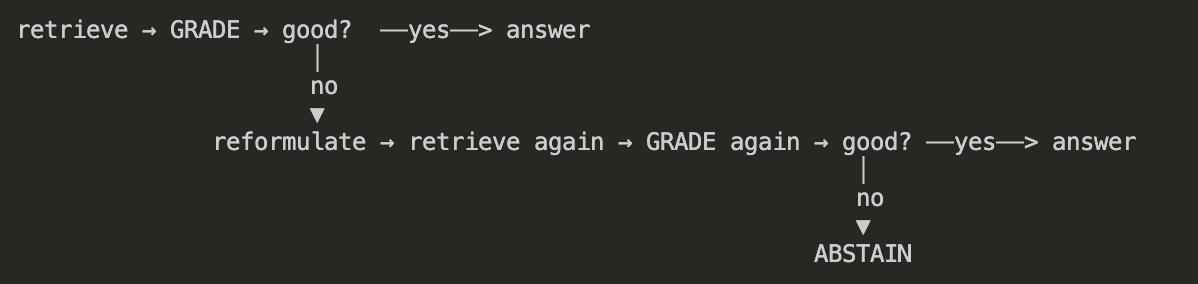

In [17]:
# Pattern 7, now INSTRUMENTED: the decision logic is identical to before, but we
# print every intermediate step so you can WATCH grade -> reformulate -> abstain unfold.
GRADE_TMPL = ("Is this context relevant AND sufficient to answer the question? "
              "Reply ONLY YES or NO.\nQuestion: {q}\nContext:\n{ctx}")

for question in ["Who is Sherlock Holmes?", "What is the capital of France?"]:
    print("=" * 88)
    print(f"Q: {question}\n")

    # 1. First retrieval — what did the vector search actually pull back?
    hits = dense_search(question)
    print("[retrieve #1] top hits (lower distance = closer):")
    show_hits(hits)
    print(f"[context #1]  grader will read: {build_context(hits)[:140].strip()!r} ...\n")

    # 2. Grade #1 — is that context good enough? (show the model's RAW reply before parsing)
    grade = ollama_chat([{"role": "user",
        "content": GRADE_TMPL.format(q=question, ctx=build_context(hits)[:2000])}], temperature=0.0)
    good = grade.strip().upper().startswith("Y")
    print(f"[grade #1]    model said {grade.strip()!r}  ->  {'GOOD' if good else 'WEAK'}\n")

    if good:
        print("[decision]    context is good -> answer directly")
        route, answer = "direct", generate(question, hits)
    else:
        # 3. Corrective step: ask the LLM to rewrite the query, then retrieve again.
        print("[decision]    context is weak -> reformulate and retry")
        new_q = ollama_chat([{"role": "user",
            "content": f"Rewrite this to retrieve better passages: {question}"}], temperature=0.2).strip()
        print(f"[rewrite]     {question!r}\n              -> {new_q!r}")

        hits = dense_search(new_q)
        print("[retrieve #2] top hits on the reformulated query:")
        show_hits(hits)

        # 4. Grade #2 — did the retry actually help?
        grade2 = ollama_chat([{"role": "user",
            "content": GRADE_TMPL.format(q=question, ctx=build_context(hits)[:2000])}], temperature=0.0)
        good2 = grade2.strip().upper().startswith("Y")
        print(f"[grade #2]    model said {grade2.strip()!r}  ->  {'GOOD' if good2 else 'WEAK'}")

        if good2:
            print("[decision]    retry worked -> answer on the reformulated retrieval")
            route, answer = "reformulated", generate(question, hits)
        else:
            print("[decision]    still weak -> ABSTAIN (don't hallucinate)")
            route, answer = "abstain", "I don't know based on the available documents."

    print(f"\nROUTE: {route}")
    print(textwrap.fill(f"A: {answer}", width=88))
    print()

Q: Who is Sherlock Holmes?

[retrieve #1] top hits (lower distance = closer):
  1. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#236]  distance=0.539
  2. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#0]  distance=0.548
  3. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#337]  distance=0.548
  4. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#39]  distance=0.551
  5. Adventures of Sherlock Holmes [adventures-of-sherlock-holmes#180]  distance=0.551
[context #1]  grader will read: '[adventures-of-sherlock-holmes#236] Adventures of Sherlock Holmes\nto you.” “You? Who are you? How could you know anything of the matter?” “M' ...

[grade #1]    model said 'YES'  ->  GOOD

[decision]    context is good -> answer directly

ROUTE: direct
A: Sherlock Holmes is a detective who solves crimes and mysteries. He is described as
having a "cold, precise but admirably balanced mind" and is known for his exceptional
abilities of observation and de

## What's next (beyond this notebook)

Patterns worth a mention but bigger to build:

- **Routing** — send each query to the right index / datasource / tool.
- **Context compression & "lost in the middle"** — LLMs under-attend to the middle of long
  contexts, so compress/summarize before stuffing and put the best hits first **and** last.
- **Smarter chunking** — recursive/structure-aware (split on headings), semantic chunking
  (split where embedding similarity drops), and small-to-big / parent-document retrieval
  (the neighbor-windowing in `v2_Local_RAG` is this in miniature).
- **GraphRAG** — build a knowledge graph for multi-hop questions.
- **Multi-modal RAG** — images, tables, and layout-aware PDF parsing.
- **Serving concerns** — streaming responses, caching, and guardrails.

In [23]:
from enum import Enum
from typing import Annotated, Literal
from pydantic import BaseModel, Field

class Role(str, Enum):
    ADMIN = "adminn"
    USER = "user"

class Address(BaseModel):
    city: str
    zip: str

class Account(BaseModel):
    owner: str
    role: Role
    tier: Literal["free", "pro", "enterprise"]
    addresses: list[Address]
    metadata: dict[str, str]
    note: str | int | None = None
    confidence: Annotated[float, Field(ge=0.0, le=1.0)]

In [27]:
admin_account = Account(owner="Ada", role="adminn", tier="pro",
                        addresses=[Address(city="New York", zip="10001")],
                        metadata={"department": "IT"}, note="Top-tier account", confidence=0.95)
user_account = Account(owner="Bob", role="user", tier="free",
                    #   addresses=[Address(city="Los Angeles", zip="90210")],
					addresses=[{"city": "Los Angeles", "zip": "90210"}],
                       metadata={"department": "Sales"}, note=None, confidence=0.8)

In [28]:
user_account.addresses

[Address(city='Los Angeles', zip='90210')]

In [25]:
admin_account.role

<Role.ADMIN: 'adminn'>

In [26]:
Role.ADMIN

<Role.ADMIN: 'adminn'>